# Compression-01 — Codes préfixes : de Shannon-Fano à Huffman

**Navigation** : [Index de la série](README.md) | [Série Complexity — voisine](../Complexity/README.md)

> **Public : Découverte.** Aucun prérequis de la série — ce carnet est le socle du
> premier pli de la sous-série Compression (format Origami : la série se déploie
> pli par pli, voir l'EPIC #18706). On y construit, de zéro, la notion de code
> préfixe, l'inégalité de Kraft, puis deux algorithmes de compression historiques :
> Shannon-Fano (1949) et Huffman (1952), avant de voir pourquoi le second bat
> toujours le premier.
>
> **Durée estimée** : 45 minutes.
>
> **Ce que vous saurez faire** : décoder un code préfixe sans jamais revenir en
> arrière ; vérifier qu'une famille de longueurs est réalisable (Kraft) ; construire
> Shannon-Fano et Huffman ; mesurer l'écart à l'entropie, la borne théorique.

In [1]:
# Imports et reglages (noyau Python, D7)
import heapq
import math

import matplotlib.pyplot as plt
import numpy as np

print("imports OK : python stdlib + numpy + matplotlib")

imports OK : python stdlib + numpy + matplotlib


## 1. Longueur fixe, longueur variable

Un fichier est une suite de symboles. Pour stocker 8 symboles différents (disons
les notes de musique de do à do), la solution la plus simple donne à chacun un
mot binaire de même longueur : 3 bits par symbole, parce que 2^3 = 8.

Cette uniformité est un gaspillage dès que les symboles ne sont pas équiprobables :
en français, le « e » est bien plus fréquent que le « k ». L'idée de la compression
**sans perte** est simple à énoncer : donner des mots courts aux symboles
fréquents, des mots longs aux symboles rares — et pouvoir relire le message sans
aucune ambiguïté.

In [2]:
SYMBOLES_8 = ["do", "re", "mi", "fa", "sol", "la", "si", "do2"]
bits_fixes = math.ceil(math.log2(len(SYMBOLES_8)))

message = ["do", "mi", "sol", "do", "la", "si", "do", "re", "mi", "do"]
cout_fixe = len(message) * bits_fixes

print(f"{len(SYMBOLES_8)} symboles distincts -> {bits_fixes} bits par symbole en longueur fixe")
print()
print(f"{'symbole':<8} | {'code fixe':<10} | bits")
print("-" * 32)
for i, s in enumerate(SYMBOLES_8):
    print(f"{s:<8} | {format(i, '03b'):<10} | {bits_fixes}")
print()
print(f"message de {len(message)} notes -> {cout_fixe} bits au total")

8 symboles distincts -> 3 bits par symbole en longueur fixe

symbole  | code fixe  | bits
--------------------------------
do       | 000        | 3
re       | 001        | 3
mi       | 010        | 3
fa       | 011        | 3
sol      | 100        | 3
la       | 101        | 3
si       | 110        | 3
do2      | 111        | 3

message de 10 notes -> 30 bits au total


**Lecture.** Avec 8 symboles, la longueur fixe coûte exactement 3 bits par note,
quelle que soit la musique. Si « do » apparaît 4 fois sur 10 dans le message, lui
donner 2 bits et 4 aux autres serait déjà un gain — à condition de savoir où
s'arrête chaque mot. C'est le problème que le code préfixe résout.

## 2. Codes préfixes : décoder sans revenir en arrière

Un code est **préfixe** si aucun mot du code n'est le début d'un autre mot du
code. C'est exactement la condition pour lire un message binaire de gauche à
droite, un seul passage : dès que les bits lus forment un mot du code, ce mot est
forcément le bon — aucun mot plus long ne peut commencer pareil.

Un arbre binaire le rend visible : chaque symbole est une feuille, chaque bit lu
descend d'un niveau (0 à gauche, 1 à droite). Un décodage est une simple marche
de la racine aux feuilles.

In [3]:
# Un code prefixe a 4 symboles, et un code AMBIGU pour comparer
code_prefixe = {"do": "00", "re": "01", "mi": "10", "sol": "11"}
code_ambigu = {"do": "0", "re": "01", "mi": "10", "sol": "110"}  # "0" prefixe de "01"


def est_prefixe(codes):
    mots = sorted(codes.values())
    for i in range(len(mots) - 1):
        if mots[i + 1].startswith(mots[i]):
            return False, (mots[i], mots[i + 1])
    return True, None


def decoder(message_bits, codes):
    inverse = {mot: symbole for symbole, mot in codes.items()}
    sortie, tampon = [], ""
    for b in message_bits:
        tampon += b
        if tampon in inverse:
            sortie.append(inverse[tampon])
            tampon = ""
    assert tampon == "", "reste non decode : le code n'est pas prefixe ?"
    return sortie


bits = "".join(code_prefixe[s] for s in ["do", "sol", "re", "mi"])
print(f"message binaire : {bits}")
print(f"decode         : {decoder(bits, code_prefixe)}")

ok, couple = est_prefixe(code_prefixe)
print(f"code a 4 symboles equiprobables prefixe ? {ok}")
ok2, couple2 = est_prefixe(code_ambigu)
print(f"code ambigu prefixe ? {ok2} -- collision : {couple2}")

message binaire : 00110110
decode         : ['do', 'sol', 're', 'mi']
code a 4 symboles equiprobables prefixe ? True
code ambigu prefixe ? False -- collision : ('0', '01')


**Lecture.** Le décodage s'arrête net à chaque mot reconnu : c'est la propriété
préfixe qui l'autorise. Le code « ambigu » échoue au test car « 0 » (do) est le
début de « 01 » (re) : à la lecture de `01...`, impossible de savoir si c'est
do suivi d'autre chose, ou re. La propriété préfixe n'est pas une option de
confort, c'est la condition d'existence du décodage en un passage.

## 3. L'inégalité de Kraft : ce qu'un code préfixe peut se permettre

Soit un code de $n$ mots de longueurs $\ell_1, \ell_2, \ldots, \ell_n$. Le code
est réalisable en préfixe **si et seulement si** :

$$\sum_{i=1}^{n} 2^{-\ell_i} \;\leq\; 1 \qquad \text{(inégalité de Kraft)}$$

Intuition : dans l'arbre binaire infini, un mot de longueur $\ell$ occupe une
feuille à profondeur $\ell$, c'est-à-dire une fraction $2^{-\ell}$ des feuilles
de cette profondeur. Les feuilles choisies ne doivent pas se chevaucher : leurs
fractions totalisent au plus 1.

On vérifie numériquement, et l'on voit aussi le cas d'égalité : quand la somme
vaut exactement 1, l'arbre est **complet** — aucun bit perdu.

In [4]:
def somme_kraft(longueurs):
    return sum(2.0 ** -l for l in longueurs)


exemples = {
    "code fixe 3 bits x 8": [3] * 8,
    "prefixe 4 symboles (2 bits)": [2, 2, 2, 2],
    "arbre complet 1+2+3+3": [1, 2, 3, 3],
    "impossible : 1+1+...": [1, 1, 2, 3],
}

print(f"{'exemple':<28} | somme Kraft | realisable en prefixe")
print("-" * 66)
for nom, ls in exemples.items():
    s = somme_kraft(ls)
    print(f"{nom:<28} | {s:<11.4f} | {'oui' if s <= 1.0 + 1e-12 else 'NON'}")

exemple                      | somme Kraft | realisable en prefixe
------------------------------------------------------------------
code fixe 3 bits x 8         | 1.0000      | oui
prefixe 4 symboles (2 bits)  | 1.0000      | oui
arbre complet 1+2+3+3        | 1.0000      | oui
impossible : 1+1+...         | 1.3750      | NON


**Lecture.** Les trois premières lignes satisfont Kraft — la dernière non : deux
mots de longueur 1 occupent déjà tout l'arbre (les deux feuilles de profondeur
1), il ne reste aucune place pour les autres symboles. Le cas « 1+2+3+3 »
atteint exactement 1 : arbre complet, chaque branche mène à un symbole utile.
Kraft ne dit pas lequel des codes réalisables est *bon* — seulement lesquels
existent.

## 4. Shannon-Fano : couper la masse en deux (1949)

L'algorithme de Shannon-Fano part des symboles triés par probabilité décroissante,
puis divise récursivement le bloc en deux groupes de masses aussi égales que
possible ; un `0` est ajouté aux mots du premier groupe, un `1` au second.

C'est un découpage **descendant** (top-down) : on décide du premier bit des mots
les plus fréquents avant de savoir comment le reste va s'agencer.

In [5]:
def shannon_fano(probs):
    """Construit le code Shannon-Fano d'une liste [(symbole, probabilite), ...]."""
    blocs = sorted(probs, key=lambda x: -x[1])
    codes = {s: "" for s, _ in blocs}

    def couper(bloc):
        if len(bloc) <= 1:
            return
        total = sum(p for _, p in bloc)
        cumul, meilleur_i, meilleur_ecart = 0.0, 0, float("inf")
        for i in range(len(bloc) - 1):
            cumul += bloc[i][1]
            ecart = abs(2 * cumul - total)  # masse a gauche vs a droite
            if ecart < meilleur_ecart:
                meilleur_ecart, meilleur_i = ecart, i
        gauche, droite = bloc[: meilleur_i + 1], bloc[meilleur_i + 1:]
        for s, _ in gauche:
            codes[s] += "0"
        for s, _ in droite:
            codes[s] += "1"
        couper(gauche)
        couper(droite)

    couper(blocs)
    return codes


DISTRIBUTION = [("do", 0.40), ("re", 0.25), ("mi", 0.15), ("fa", 0.10), ("sol", 0.06), ("la", 0.04)]
sf = shannon_fano(DISTRIBUTION)

print(f"{'symbole':<8} | {'proba':<6} | {'code SF':<8} | longueur")
print("-" * 42)
for s, p in DISTRIBUTION:
    print(f"{s:<8} | {p:<6.2f} | {sf[s]:<8} | {len(sf[s])}")

symbole  | proba  | code SF  | longueur
------------------------------------------
do       | 0.40   | 0        | 1
re       | 0.25   | 10       | 2
mi       | 0.15   | 110      | 3
fa       | 0.10   | 1110     | 4
sol      | 0.06   | 11110    | 5
la       | 0.04   | 11111    | 5


**Lecture.** Le découpage donne bien 1 bit au symbole le plus fréquent (do, 40 %)
et 4 bits aux deux plus rares. La masse totale vaut 1 ; à chaque coupe, le
« plus équilibré » des coupages possibles est choisi — mais ce choix est local :
il optimise la coupe présente, pas la longueur finale des mots.

## 5. Huffman : fusionner depuis les feuilles (1952)

Huffman procède à l'inverse : **ascendant** (bottom-up). On part des symboles
seuls, et l'on fusionne à chaque étape les deux noeuds de plus petite masse, le
noeud fusionné prenant leur somme. Le premier bit assigné l'est donc aux
symboles les *plus rares* — c'est le dernier bit décidé qui va aux fréquents.

L'algorithme est optimal : parmi tous les codes préfixes d'une distribution
donnée, Huffman minimise la longueur moyenne (preuve par échange, hors scope ici).

In [6]:
def huffman(probs):
    """Construit le code de Huffman d'une liste [(symbole, probabilite), ...]."""
    tas = [(p, i, [s]) for i, (s, p) in enumerate(probs)]
    heapq.heapify(tas)
    codes = {s: "" for s, _ in probs}
    compteur = len(probs)
    while len(tas) > 1:
        p1, _, g1 = heapq.heappop(tas)
        p2, _, g2 = heapq.heappop(tas)
        for s in g1:
            codes[s] = "0" + codes[s]
        for s in g2:
            codes[s] = "1" + codes[s]
        compteur += 1
        heapq.heappush(tas, (p1 + p2, compteur, g1 + g2))
    return codes


hu = huffman(DISTRIBUTION)

print(f"{'symbole':<8} | {'proba':<6} | {'code SF':<8} | {'code Huffman':<13} | |SF| | |Hu|")
print("-" * 66)
for s, p in DISTRIBUTION:
    print(f"{s:<8} | {p:<6.2f} | {sf[s]:<8} | {hu[s]:<13} | {len(sf[s])}   | {len(hu[s])}")

symbole  | proba  | code SF  | code Huffman  | |SF| | |Hu|
------------------------------------------------------------------
do       | 0.40   | 0        | 0             | 1   | 1
re       | 0.25   | 10       | 10            | 2   | 2
mi       | 0.15   | 110      | 110           | 3   | 3
fa       | 0.10   | 1110     | 1110          | 4   | 4
sol      | 0.06   | 11110    | 11111         | 5   | 5
la       | 0.04   | 11111    | 11110         | 5   | 5


**Lecture.** Sur cette distribution presque harmonieuse, les deux algorithmes
attribuent les mêmes longueurs — les mots diffèrent, le coût est identique.
Ce n'est pas toujours le cas, et c'est l'objet de la section suivante : il
existe des distributions où la coupe descendante de Shannon-Fano est mesurable-
ment moins bonne.

## 6. Le match : quand Shannon-Fano perd

Shannon-Fano choisit chaque coupe en équilibrant les masses *locales* ; Huffman
choisit chaque fusion en prenant les *plus petites masses restantes*. Ces deux
gloutonneries ne coïncident pas toujours : sur certaines distributions, la
première coupe de Shannon-Fano est « équilibrée » mais mal placée, et l'arbre
final laisse passer quelques centièmes de bit par symbole.

In [7]:
def longueur_moyenne(probs, codes):
    return sum(p * len(codes[s]) for s, p in probs)


def entropie(probs):
    return -sum(p * math.log2(p) for _, p in probs)


BANQUE = {
    "uniforme 8": [(f"s{i}", 1 / 8) for i in range(8)],
    "harmonieuse (sec. 4)": DISTRIBUTION,
    "fib-like": [(f"x{i}", w) for i, w in enumerate([1, 1, 2, 3, 5, 8, 13, 21])],
    "discriminante": [("A", 0.35), ("B", 0.17), ("C", 0.17), ("D", 0.16), ("E", 0.15)],
    "tres skew": [("A", 0.39), ("B", 0.21), ("C", 0.14), ("D", 0.13), ("E", 0.13)],
}

print(f"{'distribution':<22} | {'H':>6} | {'L SF':>6} | {'L Hu':>6} | SF-Hu")
print("-" * 58)
for nom, probs_brut in BANQUE.items():
    tot = sum(p for _, p in probs_brut)
    probs = [(s, p / tot) for s, p in probs_brut]
    c_sf, c_hu = shannon_fano(probs), huffman(probs)
    L_sf, L_hu = longueur_moyenne(probs, c_sf), longueur_moyenne(probs, c_hu)
    print(f"{nom:<22} | {entropie(probs):>6.4f} | {L_sf:>6.4f} | {L_hu:>6.4f} | {L_sf - L_hu:+.4f}")

distribution           |      H |   L SF |   L Hu | SF-Hu
----------------------------------------------------------
uniforme 8             | 3.0000 | 3.0000 | 3.0000 | +0.0000
harmonieuse (sec. 4)   | 2.2008 | 2.2500 | 2.2500 | +0.0000
fib-like               | 2.3714 | 2.4444 | 2.4444 | +0.0000
discriminante          | 2.2328 | 2.3100 | 2.3000 | +0.0100
tres skew              | 2.1650 | 2.2600 | 2.2200 | +0.0400


**Lecture.** Sur les trois premières distributions, égalité parfaite. Sur les
deux dernières, Shannon-Fano perd : 2,31 contre 2,30 bits, puis 2,26 contre
2,22. Le mécanisme sur la distribution « discriminante » : Huffman donne 1 bit au
symbole à 35 % (fusion 16+15, puis 17+17, puis 31+34, puis 35 contre le reste),
tandis que Shannon-Fano, en cherchant une coupe équilibrée 52/48 dès le premier
pas, condamne ce même symbole à 2 bits. Quelques centièmes de bit par symbole,
multipliés par des milliards de symboles, font des mégaoctets.

## 7. L'entropie comme borne

Peut-on faire mieux que Huffman ? La réponse tient en une inégalité : pour
**tout** code préfixe d'une source de distribution $p$, la longueur moyenne $L$
vérifie

$$H(p) \;\leq\; L, \qquad H(p) = -\sum_i p_i \log_2 p_i \quad \text{(entropie de Shannon)}$$

et Huffman reste à moins de 1 bit de cette borne : $L_{Huffman} < H(p) + 1$.
L'entropie est donc le plancher absolu (théorème du codage de source), atteint
seulement en moyennant des blocs de symboles — objet des plis suivants de la
série.

distribution           |      H |   L SF |   L Hu | H<=L ?
----------------------------------------------------------
uniforme 8             | 3.0000 | 3.0000 | 3.0000 | True
harmonieuse (sec. 4)   | 2.2008 | 2.2500 | 2.2500 | True
fib-like               | 2.3714 | 2.4444 | 2.4444 | True
discriminante          | 2.2328 | 2.3100 | 2.3000 | True
tres skew              | 2.1650 | 2.2600 | 2.2200 | True


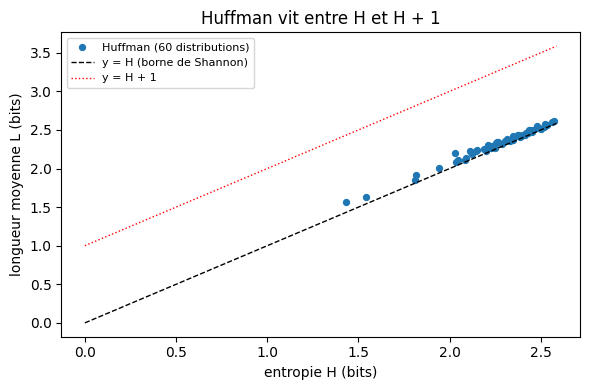

In [8]:
# Verifications : H <= L pour tout code prefixe construit ci-dessus
print(f"{'distribution':<22} | {'H':>6} | {'L SF':>6} | {'L Hu':>6} | H<=L ?")
print("-" * 58)
for nom, probs_brut in BANQUE.items():
    tot = sum(p for _, p in probs_brut)
    probs = [(s, p / tot) for s, p in probs_brut]
    H = entropie(probs)
    L_sf = longueur_moyenne(probs, shannon_fano(probs))
    L_hu = longueur_moyenne(probs, huffman(probs))
    ok = H <= L_sf + 1e-9 and H <= L_hu + 1e-9 and L_hu < H + 1
    print(f"{nom:<22} | {H:>6.4f} | {L_sf:>6.4f} | {L_hu:>6.4f} | {ok}")

# Nuage : longueur Huffman vs entropie sur des distributions aleatoires (graine fixee)
rng = np.random.default_rng(42)
Hs, Ls = [], []
for _ in range(60):
    p = rng.dirichlet(np.ones(6) * rng.uniform(0.5, 4.0))
    probs = [(f"s{i}", float(pi)) for i, pi in enumerate(p)]
    Hs.append(entropie(probs))
    Ls.append(longueur_moyenne(probs, huffman(probs)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(Hs, Ls, s=18, color="#1f77b4", label="Huffman (60 distributions)")
borne = np.linspace(0, math.log2(6), 100)
ax.plot(borne, borne, "k--", linewidth=1, label="y = H (borne de Shannon)")
ax.plot(borne, borne + 1, "r:", linewidth=1, label="y = H + 1")
ax.set_xlabel("entropie H (bits)")
ax.set_ylabel("longueur moyenne L (bits)")
ax.set_title("Huffman vit entre H et H + 1")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Lecture.** Chaque point du nuage tombe strictement entre les deux lignes :
jamais sous la borne noire (aucun code préfixe ne peut), jamais au-dessus de la
rouge (Huffman le garantit). L'écart à la borne noire se resserre quand la
distribution se rapproche de puissances de 1/2 — c'est le cas exactement
réalisable, comme le code fixe de la section 1 pour l'uniforme.

## Exercices

Les trois exercices se font dans l'ordre : vérifier qu'un code *peut exister*,
le faire *fonctionner* (encodage et décodage), puis *trouver la faille* de
Shannon-Fano par vous-même. Chaque stub s'exécute sans erreur tel quel —
complétez-le, puis relancez la cellule.

### Exercice 1 — Kraft en pratique

Un format de fichier prétend coder 6 symboles avec les longueurs
$[1, 3, 4, 4, 5, 5]$.

**Étape 1 :** écrire `satisfait_kraft(longueurs)` qui renvoie `True` si la somme
de Kraft est inférieure ou égale à 1 (à $10^{-9}$ près), `False` sinon.

**Étape 2 :** vérifier les longueurs du format ci-dessus, puis celles du code de
la section 4 (`[2, 2, 3, 4, 4, 4]`).

**Indice :** la fonction `somme_kraft` de la section 3 fait déjà la moitié du
travail — il ne reste que la comparaison.

In [9]:
def satisfait_kraft(longueurs):
    # TODO etudiant : renvoyer True si sum(2**-l) <= 1 a 1e-9 pres, False sinon
    return None


longueurs_format = [1, 3, 4, 4, 5, 5]
print("Exercice a completer : satisfait_kraft renvoie encore None")

Exercice a completer : satisfait_kraft renvoie encore None


### Exercice 2 — Encoder, décoder, vérifier

**Étape 1 :** écrire `encoder(message, codes)` qui renvoie la chaîne binaire
obtenue en remplaçant chaque symbole par son mot de code.

**Étape 2 :** écrire `decoder(bits, codes)` qui relit cette chaîne en un seul
passage, à l'aide d'un tampon qui grossit bit à bit et se vide dès qu'il forme
un mot du code (la fonction de la section 2 montre le principe).

**Étape 3 :** vérifier la rond-trip sur `["do", "sol", "re", "mi"]` avec le code
de la section 2 : l'encodage puis le décodage doivent redonner la liste exacte.

**Indice :** construire une fois le dictionnaire inverse `{mot: symbole}` avant
de boucler sur les bits.

In [10]:
def encoder(message, codes):
    # TODO etudiant : renvoyer la concatenee des mots de code des symboles
    return None


def decoder(bits, codes):
    # TODO etudiant : relire bits en un passage et renvoyer la liste des symboles
    return None


message_test = ["do", "sol", "re", "mi"]
print("Exercice a completer : encoder/decoder renvoient encore None")

Exercice a completer : encoder/decoder renvoient encore None


### Exercice 3 — Battez Shannon-Fano

**Étape 1 :** écrire `ecart_sf_huffman(probs)` qui renvoie la différence
$L_{SF} - L_{Huffman}$ d'une distribution (négatif ou nul si Shannon-Fano ne
perd pas).

**Étape 2 :** la faire tourner sur la distribution « discriminante » de la
section 6 et retrouver $+0{,}01$.

**Étape 3 :** chercher à la main une distribution de 5 symboles qui maximise
cet écart. Essayez de dépasser $0{,}04$ bit par symbole.

**Indice :** pour que Shannon-Fano perde, il faut que sa *première coupe
équilibrée* sépare mal les symboles fréquents — une masse dominante autour de
0,35 à 0,40 et quatre petites masses comparables font l'affaire.

In [11]:
def ecart_sf_huffman(probs):
    # TODO etudiant : renvoyer longueur_moyenne(SF) - longueur_moyenne(Huffman)
    return None


ma_distribution = [("A", 0.35), ("B", 0.17), ("C", 0.17), ("D", 0.16), ("E", 0.15)]
print("Exercice a completer : ecart_sf_huffman renvoie encore None")

Exercice a completer : ecart_sf_huffman renvoie encore None


## Conclusion

| Notion | Ce qu'elle dit | Où la voir |
|---|---|---|
| Code préfixe | aucun mot n'est préfixe d'un autre ; décodage en un passage | section 2 |
| Kraft | $\sum 2^{-\ell_i} \leq 1$ : les longueurs réalisables | section 3 |
| Shannon-Fano | coupe descendante équilibrée ; simple, parfois sous-optimal | sections 4 et 6 |
| Huffman | fusion ascendante des plus petites masses ; optimal parmi les préfixes | sections 5 et 6 |
| Entropie | $H \leq L$ pour tout code préfixe, Huffman à moins de 1 de $H$ | section 7 |

Ce premier pli a posé le socle : symboles, mots, arbres, et la borne. Les plis
suivants (format Origami, ouverts à la livraison de celui-ci — EPIC #18706)
traitent du codage par blocs qui approche la borne, des codecs réels, et du
jumeau Lean des définitions.

**Pour aller plus loin** : la série voisine
[Complexity](../Complexity/README.md) traite du coût de *calculer* — ici on a
traité du coût de *représenter* ; les deux questions se rejoignent dans le
compromis temps de calcul contre taille de sortie.

**Références**

- C. E. Shannon, *A Mathematical Theory of Communication*, 1948.
- R. M. Fano, *The Transmission of Information*, 1949 (technique de coupe).
- D. A. Huffman, *A Method for the Construction of Minimum-Redundancy Codes*, 1952.
- T. M. Cover, J. A. Thomas, *Elements of Information Theory*, 2e éd., 2006, chap. 5.